<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/OrbitalLaunchesFinalReport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORTING THE DATA**

In [2]:
# Importing necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import random

In [3]:
# Uploading dataset into Colab
from google.colab import files
uploaded = files.upload()

Saving jsr_unique_launches_1957_2024.csv to jsr_unique_launches_1957_2024.csv


In [4]:
# Loading the dataset
import pandas as pd
launchdf = pd.read_csv("jsr_unique_launches_1957_2024.csv")
launchdf.head()

,launch_id,dt_min,year,site_raw,pad_raw,vehicle,agency,lv_state,launch_code,success,n_payload_rows,success_hard
0,1957-10-04 19:28 | niip-5 | lc1 | sputnik 8k71...,1957-10-04T19:28:00Z,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,OS,True,1,True
1,1957-11-03 02:30 | niip-5 | lc1 | sputnik 8k71...,1957-11-03T02:30:00Z,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,OS,True,1,True
2,1957-12-06 16:44 | cc | lc18a | vanguard | tv-3,1957-12-06T16:44:00Z,1957,CC,LC18A,Vanguard,NRL,US,OF,False,1,False
3,1958-02-01 03:47 | cc | lc26a | jupiter c | rs...,1958-02-01T03:47:00Z,1958,CC,LC26A,Jupiter C,ABMA,US,OS,True,1,True
4,1958-02-05 07:33 | cc | lc18a | vanguard | tv-3bu,1958-02-05T07:33:00Z,1958,CC,LC18A,Vanguard,NRL,US,OF,False,1,False


# **PERFORMING EDA (EXPLORATORY DATA ANALYSIS)**

In [ ]:
# Viewing the dimensions of the dataset structure
launchdf.shape

(6617, 12)

In [ ]:
# Viewing a technical summary of the dataset
launchdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6617 entries, 0 to 6616
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   launch_id       6617 non-null   object
 1   dt_min          6617 non-null   object
 2   year            6617 non-null   int64 
 3   site_raw        6617 non-null   object
 4   pad_raw         6617 non-null   object
 5   vehicle         6617 non-null   object
 6   agency          6617 non-null   object
 7   lv_state        6617 non-null   object
 8   launch_code     6617 non-null   object
 9   success         6504 non-null   object
 10  n_payload_rows  6617 non-null   int64 
 11  success_hard    6617 non-null   bool  
dtypes: bool(1), int64(2), object(9)
memory usage: 575.2+ KB


In [ ]:
# Viewing if there are missing values in the dataset
launchdf.isnull().sum()

,0
launch_id,0
dt_min,0
year,0
site_raw,0
pad_raw,0
vehicle,0
agency,0
lv_state,0
launch_code,0
success,113


In [ ]:
# Using Sweetviz to view an initial report
!pip install sweetviz
import sweetviz as sv
report = sv.analyze(launchdf)
report.show_html('launchdf_report.html')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 81.3 MB/s eta 0:00:00


                                             |          | [  0%]   00:00 -> (? left)

Report launchdf_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Exploring target variable balance - success_hard**

In [ ]:
launchdf["success_hard"].value_counts()

,count
success_hard,
True,6126
False,491


In [ ]:
launchdf["success_hard"].value_counts(normalize=True)

,proportion
success_hard,
True,0.925797
False,0.074203


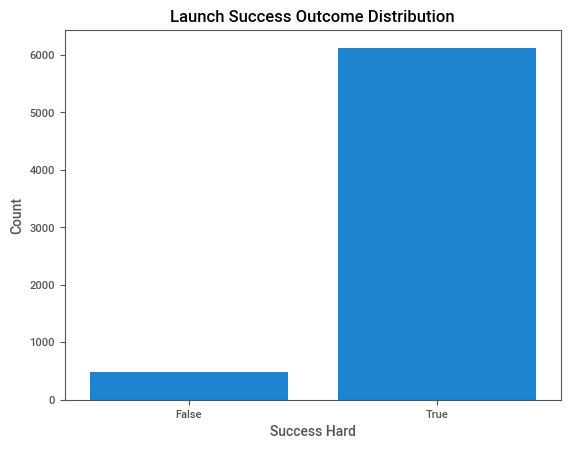

In [ ]:
sns.countplot(x="success_hard", data=launchdf)
plt.title("Launch Success Outcome Distribution")
plt.xlabel("Success Hard")
plt.ylabel("Count")
plt.show()

Questions:

Are failures rare?
Is accuracy misleading?
Should F1/ROC AUC matter more?

**Launch frequency over time**

In [ ]:
launchdf.groupby("year").size()

,0
year,
1957,3
1958,28
1959,19
1960,37
1961,49
...,...
2020,109
2021,144
2022,182


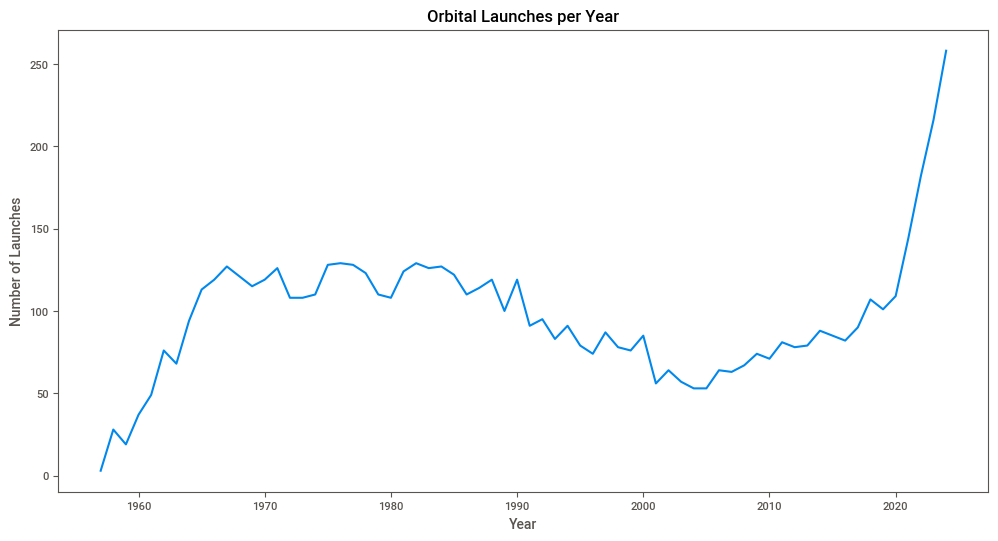

In [ ]:
launches_per_year = launchdf.groupby("year").size()

plt.figure(figsize=(12,6))
plt.plot(launches_per_year.index, launches_per_year.values)
plt.title("Orbital Launches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.show()

Questions:

When did launches accelerate?
Does SpaceX/commercialization change trends?


**Success rate over time**

In [ ]:
launchdf.groupby("year")["success_hard"].mean()

,success_hard
year,
1957,0.666667
1958,0.285714
1959,0.473684
1960,0.486486
1961,0.632653
...,...
2020,0.908257
2021,0.923611
2022,0.961538


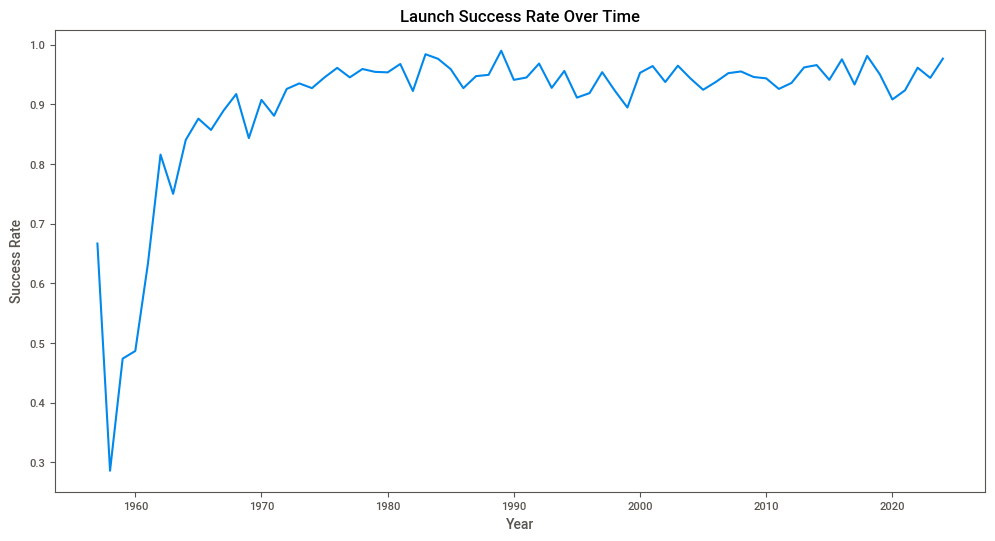

In [ ]:
success_rate_year = launchdf.groupby("year")["success_hard"].mean()

plt.figure(figsize=(12,6))
plt.plot(success_rate_year.index, success_rate_year.values)
plt.title("Launch Success Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Success Rate")
plt.show()

Questions:

Has reliability improved?
Are modern launches safer?
Is year predictive?



**Top agencies**

In [ ]:
launchdf["agency"].value_counts().head(10)

,count
agency,
RVSN,1482
UNKS,898
SPX,427
CALT,317
AE,288
AFSSD,243
SAST,237
VKSR,197
GSFC,175


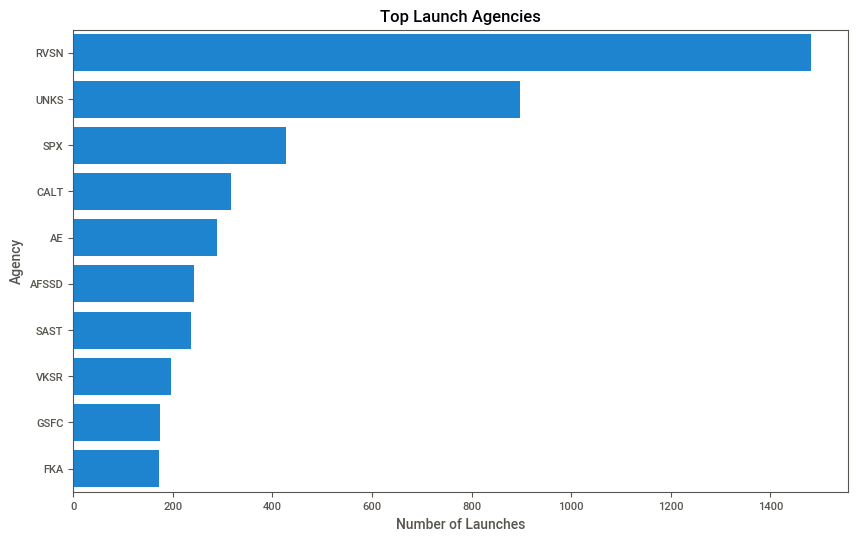

In [ ]:
# Showing launches by agency
top_agencies = launchdf["agency"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_agencies.values, y=top_agencies.index)
plt.title("Top Launch Agencies")
plt.xlabel("Number of Launches")
plt.ylabel("Agency")
plt.show()

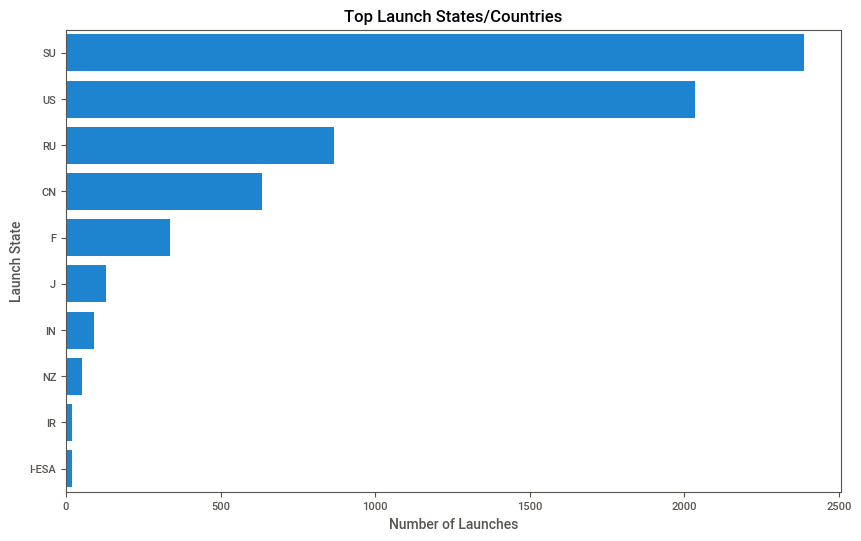

In [ ]:
# Plotting launches by state/country
top_states = launchdf["lv_state"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top Launch States/Countries")
plt.xlabel("Number of Launches")
plt.ylabel("Launch State")
plt.show()

Questions:

Which agencies dominate orbital launches?
Which are newer entrants?
Do agencies differ in reliability?

**Success rate by agency**

In [ ]:
launchdf.groupby("agency")["success_hard"].mean()

,success_hard
agency,
10ADS,1.000000
2SLS/AFSMC,1.000000
3SLS/AFSMC,0.812500
4SLS/AFSMC,1.000000
ABLSS,0.000000
...,...
VORB,0.666667
VVKO,0.970588
XIDO,0.941176


Questions:

Which agencies are most reliable?
Does launch volume correlate with reliability?

**Top launch vehicles**

In [ ]:
launchdf["vehicle"].value_counts().head(20)

,count
vehicle,
Soyuz-U,633
Kosmos 11K65M,445
Falcon 9,408
Voskhod 11A57,299
Molniya 8K78M,259
Soyuz-U-PVB,154
Space Shuttle,132
Kosmos 11K63,126
Tsiklon-3,122


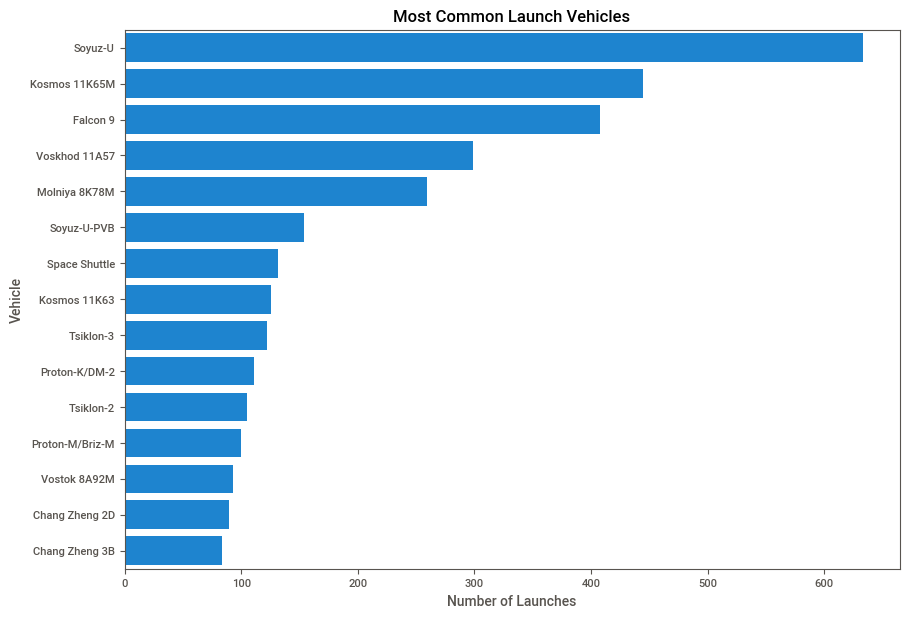

In [ ]:
# Showing the frequency of vehicles
top_vehicles = launchdf["vehicle"].value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_vehicles.values, y=top_vehicles.index)
plt.title("Most Common Launch Vehicles")
plt.xlabel("Number of Launches")
plt.ylabel("Vehicle")
plt.show()

Questions:

Which rockets dominate historically?
Are some vehicles much more reliable?

**Launch site analysis**

In [ ]:
launchdf["site_raw"].value_counts()

,count
site_raw,
NIIP-53,1414
CC,869
NIIP-5,827
GIK-5,656
VS,341
...,...
SPFL,1
NEWQ,1
TYSC?,1


**Correlations in the data**

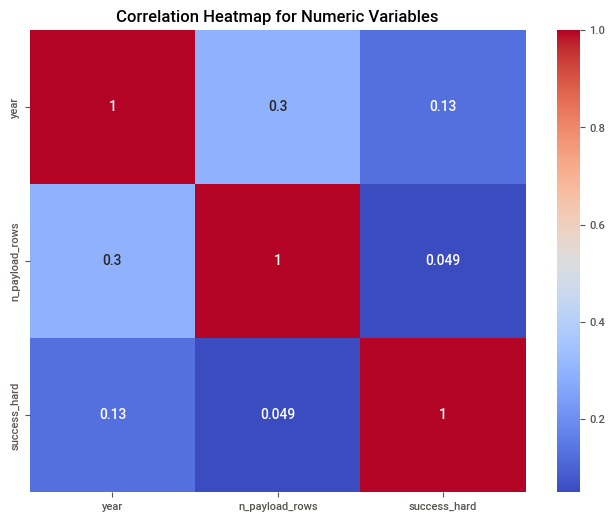

In [ ]:
numeric_cols = launchdf.select_dtypes(include=["int64", "float64", "bool"]).columns

corr = launchdf[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Numeric Variables")
plt.show()

# **DATA PREPARATION**

In [ ]:
# Creating a working copy of dataset
launchdf_clean = launchdf.copy()

In [ ]:
# Removing duplicate rows if needed
#launchdf_clean = launchdf_clean.drop_duplicates()

In [ ]:
# Converting launch datetime to datetime format
launchdf_clean["dt_min"] = pd.to_datetime(
    launchdf_clean["dt_min"]
)

In [ ]:
# Verifying missing values after inspection
launchdf_clean.isnull().sum()
# I will likely just drop "success" anyway so missing values here is okay.

,0
launch_id,0
dt_min,0
year,0
site_raw,0
pad_raw,0
vehicle,0
agency,0
lv_state,0
launch_code,0
success,113


In [ ]:
# Checking cleaned datatypes
launchdf_clean.dtypes

,0
launch_id,object
dt_min,"datetime64[ns, UTC]"
year,int64
site_raw,object
pad_raw,object
vehicle,object
agency,object
lv_state,object
launch_code,object
success,object


Analyzing how well the original features perform on a baseline model

In [ ]:
# ORIGINAL FEATURE DATASET

# drop columns not used for prediction
# ORIGINAL FEATURE DATASET WITHOUT LEAKAGE

launchdf_original = launchdf_clean.drop(
    columns=[
        "launch_id",
        "success",
        "launch_code"
    ]
)

launchdf_original["success_hard"] = launchdf_original["success_hard"].astype(int)

X_original = launchdf_original.drop(columns=["success_hard"])
y_original = launchdf_original["success_hard"]

print(X_original.shape)
print(y_original.shape)

X_original.head()

(6617, 8)
(6617,)


,dt_min,year,site_raw,pad_raw,vehicle,agency,lv_state,n_payload_rows
0,1957-10-04 19:28:00+00:00,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,1
1,1957-11-03 02:30:00+00:00,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,1
2,1957-12-06 16:44:00+00:00,1957,CC,LC18A,Vanguard,NRL,US,1
3,1958-02-01 03:47:00+00:00,1958,CC,LC26A,Jupiter C,ABMA,US,1
4,1958-02-05 07:33:00+00:00,1958,CC,LC18A,Vanguard,NRL,US,1


In [ ]:
# TRAIN / TEST SPLIT
# ORIGINAL FEATURES

from sklearn.model_selection import train_test_split

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    stratify=y_original,
    random_state=42
)

print("Training set shape:", X_train_orig.shape)
print("Test set shape:", X_test_orig.shape)

print("\nTraining target distribution:")
print(y_train_orig.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test_orig.value_counts(normalize=True))

Training set shape: (5293, 8)
Test set shape: (1324, 8)

Training target distribution:
success_hard
1    0.925751
0    0.074249
Name: proportion, dtype: float64

Test target distribution:
success_hard
1    0.925982
0    0.074018
Name: proportion, dtype: float64


In [ ]:
# PREPROCESS ORIGINAL FEATURES

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# create a usable numeric datetime feature
X_train_orig = X_train_orig.copy()
X_test_orig = X_test_orig.copy()

X_train_orig["launch_timestamp"] = (
    X_train_orig["dt_min"].astype("int64") // 10**9
)

X_test_orig["launch_timestamp"] = (
    X_test_orig["dt_min"].astype("int64") // 10**9
)

# drop original datetime column
X_train_orig = X_train_orig.drop(columns=["dt_min"])
X_test_orig = X_test_orig.drop(columns=["dt_min"])

# identify categorical and numeric columns
categorical_features_orig = X_train_orig.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features_orig = X_train_orig.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features_orig)

print("\nNumeric Features:")
print(numeric_features_orig)

# preprocessing pipeline
preprocessor_orig = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_orig
        )
    ],
    remainder="passthrough"
)

# fit and transform training data
X_train_orig_processed = preprocessor_orig.fit_transform(
    X_train_orig
)

# transform test data
X_test_orig_processed = preprocessor_orig.transform(
    X_test_orig
)

print("\nProcessed training shape:")
print(X_train_orig_processed.shape)

print("\nProcessed test shape:")
print(X_test_orig_processed.shape)

Categorical Features:
['site_raw', 'pad_raw', 'vehicle', 'agency', 'lv_state']

Numeric Features:
['year', 'n_payload_rows', 'launch_timestamp']

Processed training shape:
(5293, 775)

Processed test shape:
(1324, 775)


In [ ]:
# BASELINE RANDOM FOREST
# ORIGINAL FEATURES

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# initialize model
rf_original = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# train model
rf_original.fit(
    X_train_orig_processed,
    y_train_orig
)

# predictions
y_pred_orig = rf_original.predict(
    X_test_orig_processed
)

# prediction probabilities
y_prob_orig = rf_original.predict_proba(
    X_test_orig_processed
)[:, 1]

# evaluation metrics
accuracy_orig = accuracy_score(
    y_test_orig,
    y_pred_orig
)

precision_orig = precision_score(
    y_test_orig,
    y_pred_orig
)

recall_orig = recall_score(
    y_test_orig,
    y_pred_orig
)

f1_orig = f1_score(
    y_test_orig,
    y_pred_orig
)

roc_auc_orig = roc_auc_score(
    y_test_orig,
    y_prob_orig
)

# print results
print("=== Random Forest: Original Features ===")

print(f"Accuracy: {accuracy_orig:.4f}")
print(f"Precision: {precision_orig:.4f}")
print(f"Recall: {recall_orig:.4f}")
print(f"F1 Score: {f1_orig:.4f}")
print(f"ROC AUC: {roc_auc_orig:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_orig,
        y_pred_orig
    )
)

=== Random Forest: Original Features ===
Accuracy: 0.9109
Precision: 0.9369
Recall: 0.9690
F1 Score: 0.9527
ROC AUC: 0.7183

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.18      0.23        98
           1       0.94      0.97      0.95      1226

    accuracy                           0.91      1324
   macro avg       0.63      0.58      0.59      1324
weighted avg       0.89      0.91      0.90      1324



In [ ]:
# TOP FEATURE IMPORTANCES
# ORIGINAL RANDOM FOREST

# retrieve feature names after one-hot encoding
feature_names_orig = preprocessor_orig.get_feature_names_out()

# create dataframe
feature_importance_orig = pd.DataFrame({
    "Feature": feature_names_orig,
    "Importance": rf_original.feature_importances_
})

# sort descending
feature_importance_orig = feature_importance_orig.sort_values(
    by="Importance",
    ascending=False
)

# display top 20
feature_importance_orig.head(20)

,Feature,Importance
774,remainder__launch_timestamp,0.253645
772,remainder__year,0.166634
773,remainder__n_payload_rows,0.046623
537,cat__vehicle_Soyuz-U,0.009285
29,cat__site_raw_NIIP-53,0.009207
411,cat__vehicle_Falcon 9,0.007995
622,cat__vehicle_Voskhod 11A57,0.006599
454,cat__vehicle_Molniya 8K78,0.006325
136,cat__pad_raw_LC31,0.005989
740,cat__agency_SPX,0.005876


The model is mostly learning:
“Most launches succeed.”

The model performs well on the majority class (success=1) but poorly on failures (success=0).


Accuracy alone is misleading,
ROC AUC and minority-class performance matter more.


Feature engineering and testing if this improves the model.

In [ ]:
# FEATURE ENGINEERING DATASET

# Start from cleaned dataset
launchdf_engineered = launchdf_clean.copy()

# Convert target to integer
launchdf_engineered["success_hard"] = launchdf_engineered["success_hard"].astype(int)

# Drop non-predictive or leakage columns
launchdf_engineered = launchdf_engineered.drop(
    columns=[
        "launch_id",     # unique identifier
        "success",       # redundant/leakage-related outcome variable
        "launch_code"    # removed because it leaked launch outcome information
    ]
)

In [ ]:
# TEMPORAL FEATURES

# Launch decade
launchdf_engineered["launch_decade"] = (
    launchdf_engineered["year"] // 10
) * 10

# Commercial space era indicator
launchdf_engineered["commercial_era"] = (
    launchdf_engineered["year"] >= 2010
).astype(int)

# Years since first orbital launch
launchdf_engineered["years_since_1957"] = (
    launchdf_engineered["year"] - 1957
)

In [ ]:
# OPERATIONAL FREQUENCY FEATURES

# Total launches by agency
agency_launch_counts = launchdf_engineered["agency"].value_counts()

launchdf_engineered["agency_launch_count"] = (
    launchdf_engineered["agency"].map(agency_launch_counts)
)

# Total launches by vehicle
vehicle_launch_counts = launchdf_engineered["vehicle"].value_counts()

launchdf_engineered["vehicle_launch_count"] = (
    launchdf_engineered["vehicle"].map(vehicle_launch_counts)
)

# Total launches by launch state/country
state_launch_counts = launchdf_engineered["lv_state"].value_counts()

launchdf_engineered["state_launch_count"] = (
    launchdf_engineered["lv_state"].map(state_launch_counts)
)

In [ ]:
# RARE CATEGORY GROUPING

# Group less common agencies into OTHER
top_agencies = launchdf_engineered["agency"].value_counts().nlargest(15).index

launchdf_engineered["agency_grouped"] = (
    launchdf_engineered["agency"]
    .apply(lambda x: x if x in top_agencies else "OTHER")
)

# Group less common vehicles into OTHER
top_vehicles = launchdf_engineered["vehicle"].value_counts().nlargest(20).index

launchdf_engineered["vehicle_grouped"] = (
    launchdf_engineered["vehicle"]
    .apply(lambda x: x if x in top_vehicles else "OTHER")
)

In [ ]:
# FINAL ENGINEERED FEATURE SET

X_engineered = launchdf_engineered.drop(columns=["success_hard"])
y_engineered = launchdf_engineered["success_hard"]

print("Engineered X shape:", X_engineered.shape)
print("Engineered y shape:", y_engineered.shape)

launchdf_engineered.head()

Engineered X shape: (6617, 16)
Engineered y shape: (6617,)


,dt_min,year,site_raw,pad_raw,vehicle,agency,lv_state,n_payload_rows,success_hard,launch_decade,commercial_era,years_since_1957,agency_launch_count,vehicle_launch_count,state_launch_count,agency_grouped,vehicle_grouped
0,1957-10-04 19:28:00+00:00,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,1,1,1950,0,0,8,2,2388,OTHER,OTHER
1,1957-11-03 02:30:00+00:00,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,1,1,1950,0,0,8,2,2388,OTHER,OTHER
2,1957-12-06 16:44:00+00:00,1957,CC,LC18A,Vanguard,NRL,US,1,0,1950,0,0,11,11,2034,OTHER,OTHER
3,1958-02-01 03:47:00+00:00,1958,CC,LC26A,Jupiter C,ABMA,US,1,1,1950,0,1,10,6,2034,OTHER,OTHER
4,1958-02-05 07:33:00+00:00,1958,CC,LC18A,Vanguard,NRL,US,1,0,1950,0,1,11,11,2034,OTHER,OTHER


In [ ]:
# TRAIN / TEST SPLIT
# ENGINEERED FEATURES

from sklearn.model_selection import train_test_split

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    stratify=y_engineered,
    random_state=42
)

print("Training set shape:", X_train_eng.shape)
print("Test set shape:", X_test_eng.shape)

Training set shape: (5293, 16)
Test set shape: (1324, 16)


In [ ]:
# PREPROCESS ENGINEERED FEATURES

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_train_eng = X_train_eng.copy()
X_test_eng = X_test_eng.copy()

# convert datetime into numeric timestamp
X_train_eng["launch_timestamp"] = X_train_eng["dt_min"].astype("int64") // 10**9
X_test_eng["launch_timestamp"] = X_test_eng["dt_min"].astype("int64") // 10**9

# drop original datetime column
X_train_eng = X_train_eng.drop(columns=["dt_min"])
X_test_eng = X_test_eng.drop(columns=["dt_min"])

categorical_features_eng = X_train_eng.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features_eng = X_train_eng.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features_eng)

print("\nNumeric Features:")
print(numeric_features_eng)

preprocessor_eng = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_eng)
    ],
    remainder="passthrough"
)

X_train_eng_processed = preprocessor_eng.fit_transform(X_train_eng)
X_test_eng_processed = preprocessor_eng.transform(X_test_eng)

print("\nProcessed engineered training shape:", X_train_eng_processed.shape)
print("Processed engineered test shape:", X_test_eng_processed.shape)

Categorical Features:
['site_raw', 'pad_raw', 'vehicle', 'agency', 'lv_state', 'agency_grouped', 'vehicle_grouped']

Numeric Features:
['year', 'n_payload_rows', 'launch_decade', 'commercial_era', 'years_since_1957', 'agency_launch_count', 'vehicle_launch_count', 'state_launch_count', 'launch_timestamp']

Processed engineered training shape: (5293, 818)
Processed engineered test shape: (1324, 818)


In [ ]:
# RANDOM FOREST
# ENGINEERED FEATURES

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# initialize model
rf_engineered = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# train model
rf_engineered.fit(
    X_train_eng_processed,
    y_train_eng
)

# predictions
y_pred_eng = rf_engineered.predict(
    X_test_eng_processed
)

# prediction probabilities
y_prob_eng = rf_engineered.predict_proba(
    X_test_eng_processed
)[:, 1]

# evaluation metrics
accuracy_eng = accuracy_score(
    y_test_eng,
    y_pred_eng
)

precision_eng = precision_score(
    y_test_eng,
    y_pred_eng
)

recall_eng = recall_score(
    y_test_eng,
    y_pred_eng
)

f1_eng = f1_score(
    y_test_eng,
    y_pred_eng
)

roc_auc_eng = roc_auc_score(
    y_test_eng,
    y_prob_eng
)

# print results
print("=== Random Forest: Engineered Features ===")

print(f"Accuracy: {accuracy_eng:.4f}")
print(f"Precision: {precision_eng:.4f}")
print(f"Recall: {recall_eng:.4f}")
print(f"F1 Score: {f1_eng:.4f}")
print(f"ROC AUC: {roc_auc_eng:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_eng,
        y_pred_eng
    )
)

=== Random Forest: Engineered Features ===
Accuracy: 0.9094
Precision: 0.9368
Recall: 0.9674
F1 Score: 0.9518
ROC AUC: 0.7304

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.18      0.23        98
           1       0.94      0.97      0.95      1226

    accuracy                           0.91      1324
   macro avg       0.62      0.58      0.59      1324
weighted avg       0.89      0.91      0.90      1324



In [ ]:
# TOP FEATURE IMPORTANCES
# ENGINEERED DATASET

# retrieve feature names
feature_names_eng = preprocessor_eng.get_feature_names_out()

# create feature importance dataframe
feature_importance_eng = pd.DataFrame({
    "Feature": feature_names_eng,
    "Importance": rf_engineered.feature_importances_
})

# sort descending
feature_importance_eng = feature_importance_eng.sort_values(
    by="Importance",
    ascending=False
)

# display top 20
feature_importance_eng.head(20)

,Feature,Importance
817,remainder__launch_timestamp,0.192097
809,remainder__year,0.105811
813,remainder__years_since_1957,0.105254
815,remainder__vehicle_launch_count,0.062000
810,remainder__n_payload_rows,0.038851
814,remainder__agency_launch_count,0.033164
811,remainder__launch_decade,0.031903
796,cat__vehicle_grouped_OTHER,0.021631
816,remainder__state_launch_count,0.011014
781,cat__agency_grouped_OTHER,0.008104


Engineered features did NOT dramatically improve majority-class prediction, but they DID slightly improve discriminatory power.

Historical/operational features contain useful information,
but predicting failures remains difficult,
likely because failures are rare and influenced by factors not present in the dataset.


In [ ]:
# MODEL PERFORMANCE COMPARISON

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Original Features": [
        accuracy_orig,
        precision_orig,
        recall_orig,
        f1_orig,
        roc_auc_orig
    ],

    "Engineered Features": [
        accuracy_eng,
        precision_eng,
        recall_eng,
        f1_eng,
        roc_auc_eng
    ]
})

# round values for readability
comparison_df = comparison_df.round(4)

comparison_df

,Metric,Original Features,Engineered Features
0,Accuracy,0.9109,0.9094
1,Precision,0.9369,0.9368
2,Recall,0.9690,0.9674
3,F1 Score,0.9527,0.9518
4,ROC AUC,0.7183,0.7304


Trying out one more thing before making a final selection of features.

In [ ]:
# REFINED ENGINEERED DATASET

important_features = [
    "dt_min",
    "year",
    "site_raw",
    "pad_raw",
    "vehicle",
    "agency",
    "lv_state",
    "n_payload_rows",
    "launch_decade",
    "years_since_1957",
    "agency_launch_count",
    "vehicle_launch_count",
    "state_launch_count",
    "agency_grouped",
    "vehicle_grouped",
    "success_hard"
]

launchdf_refined = launchdf_engineered[
    important_features
].copy()

launchdf_refined.head()

,dt_min,year,site_raw,pad_raw,vehicle,agency,lv_state,n_payload_rows,launch_decade,years_since_1957,agency_launch_count,vehicle_launch_count,state_launch_count,agency_grouped,vehicle_grouped,success_hard
0,1957-10-04 19:28:00+00:00,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,1,1950,0,8,2,2388,OTHER,OTHER,1
1,1957-11-03 02:30:00+00:00,1957,NIIP-5,LC1,Sputnik 8K71PS,MVS,SU,1,1950,0,8,2,2388,OTHER,OTHER,1
2,1957-12-06 16:44:00+00:00,1957,CC,LC18A,Vanguard,NRL,US,1,1950,0,11,11,2034,OTHER,OTHER,0
3,1958-02-01 03:47:00+00:00,1958,CC,LC26A,Jupiter C,ABMA,US,1,1950,1,10,6,2034,OTHER,OTHER,1
4,1958-02-05 07:33:00+00:00,1958,CC,LC18A,Vanguard,NRL,US,1,1950,1,11,11,2034,OTHER,OTHER,0


In [ ]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.5 MB/s eta 0:00:00


In [ ]:
from feature_engine.encoding import RareLabelEncoder

# apply rare category grouping

rare_encoder = RareLabelEncoder(
    tol=0.01,
    variables=[
        "site_raw",
        "pad_raw",
        "vehicle",
        "agency"
    ]
)

launchdf_refined = rare_encoder.fit_transform(
    launchdf_refined
)

launchdf_refined.head()

,dt_min,year,site_raw,pad_raw,vehicle,agency,lv_state,n_payload_rows,launch_decade,years_since_1957,agency_launch_count,vehicle_launch_count,state_launch_count,agency_grouped,vehicle_grouped,success_hard
0,1957-10-04 19:28:00+00:00,1957,NIIP-5,LC1,Rare,Rare,SU,1,1950,0,8,2,2388,OTHER,OTHER,1
1,1957-11-03 02:30:00+00:00,1957,NIIP-5,LC1,Rare,Rare,SU,1,1950,0,8,2,2388,OTHER,OTHER,1
2,1957-12-06 16:44:00+00:00,1957,CC,Rare,Rare,Rare,US,1,1950,0,11,11,2034,OTHER,OTHER,0
3,1958-02-01 03:47:00+00:00,1958,CC,Rare,Rare,Rare,US,1,1950,1,10,6,2034,OTHER,OTHER,1
4,1958-02-05 07:33:00+00:00,1958,CC,Rare,Rare,Rare,US,1,1950,1,11,11,2034,OTHER,OTHER,0


In [ ]:
# TRAIN / TEST SPLIT
# REFINED ENGINEERED FEATURES

X_refined = launchdf_refined.drop(columns=["success_hard"])
y_refined = launchdf_refined["success_hard"]

X_train_refined, X_test_refined, y_train_refined, y_test_refined = train_test_split(
    X_refined,
    y_refined,
    test_size=0.2,
    stratify=y_refined,
    random_state=42
)

print("Training set shape:", X_train_refined.shape)
print("Test set shape:", X_test_refined.shape)

Training set shape: (5293, 15)
Test set shape: (1324, 15)


In [ ]:
# PREPROCESS REFINED FEATURES

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# create copies
X_train_refined = X_train_refined.copy()
X_test_refined = X_test_refined.copy()

# convert datetime into numeric timestamp
X_train_refined["launch_timestamp"] = (
    X_train_refined["dt_min"].astype("int64") // 10**9
)

X_test_refined["launch_timestamp"] = (
    X_test_refined["dt_min"].astype("int64") // 10**9
)

# drop original datetime column
X_train_refined = X_train_refined.drop(columns=["dt_min"])
X_test_refined = X_test_refined.drop(columns=["dt_min"])

# identify categorical and numeric columns
categorical_features_refined = X_train_refined.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features_refined = X_train_refined.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features_refined)

print("\nNumeric Features:")
print(numeric_features_refined)

# preprocessing pipeline
preprocessor_refined = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_refined
        )
    ],
    remainder="passthrough"
)

# fit and transform training data
X_train_refined_processed = preprocessor_refined.fit_transform(
    X_train_refined
)

# transform test data
X_test_refined_processed = preprocessor_refined.transform(
    X_test_refined
)

print("\nProcessed refined training shape:")
print(X_train_refined_processed.shape)

print("\nProcessed refined test shape:")
print(X_test_refined_processed.shape)

Categorical Features:
['site_raw', 'pad_raw', 'vehicle', 'agency', 'lv_state', 'agency_grouped', 'vehicle_grouped']

Numeric Features:
['year', 'n_payload_rows', 'launch_decade', 'years_since_1957', 'agency_launch_count', 'vehicle_launch_count', 'state_launch_count', 'launch_timestamp']

Processed refined training shape:
(5293, 149)

Processed refined test shape:
(1324, 149)


In [ ]:
# RANDOM FOREST
# REFINED ENGINEERED FEATURES

rf_refined = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_refined.fit(
    X_train_refined_processed,
    y_train_refined
)

y_pred_refined = rf_refined.predict(X_test_refined_processed)

y_prob_refined = rf_refined.predict_proba(X_test_refined_processed)[:, 1]

accuracy_refined = accuracy_score(y_test_refined, y_pred_refined)
precision_refined = precision_score(y_test_refined, y_pred_refined)
recall_refined = recall_score(y_test_refined, y_pred_refined)
f1_refined = f1_score(y_test_refined, y_pred_refined)
roc_auc_refined = roc_auc_score(y_test_refined, y_prob_refined)

print("=== Random Forest: Refined Engineered Features ===")
print(f"Accuracy: {accuracy_refined:.4f}")
print(f"Precision: {precision_refined:.4f}")
print(f"Recall: {recall_refined:.4f}")
print(f"F1 Score: {f1_refined:.4f}")
print(f"ROC AUC: {roc_auc_refined:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_refined, y_pred_refined))

=== Random Forest: Refined Engineered Features ===
Accuracy: 0.9101
Precision: 0.9375
Recall: 0.9674
F1 Score: 0.9522
ROC AUC: 0.7206

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.19      0.24        98
           1       0.94      0.97      0.95      1226

    accuracy                           0.91      1324
   macro avg       0.63      0.58      0.60      1324
weighted avg       0.89      0.91      0.90      1324



In [ ]:
# RANDOM FOREST COMPARISON

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Original Features": [
        accuracy_orig,
        precision_orig,
        recall_orig,
        f1_orig,
        roc_auc_orig
    ],

    "Engineered Features": [
        accuracy_eng,
        precision_eng,
        recall_eng,
        f1_eng,
        roc_auc_eng
    ],

    "Refined Engineered Features": [
        accuracy_refined,
        precision_refined,
        recall_refined,
        f1_refined,
        roc_auc_refined
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Metric,Original Features,Engineered Features,Refined Engineered Features
0,Accuracy,0.9109,0.9094,0.9101
1,Precision,0.9369,0.9368,0.9375
2,Recall,0.9690,0.9674,0.9674
3,F1 Score,0.9527,0.9518,0.9522
4,ROC AUC,0.7183,0.7304,0.7206


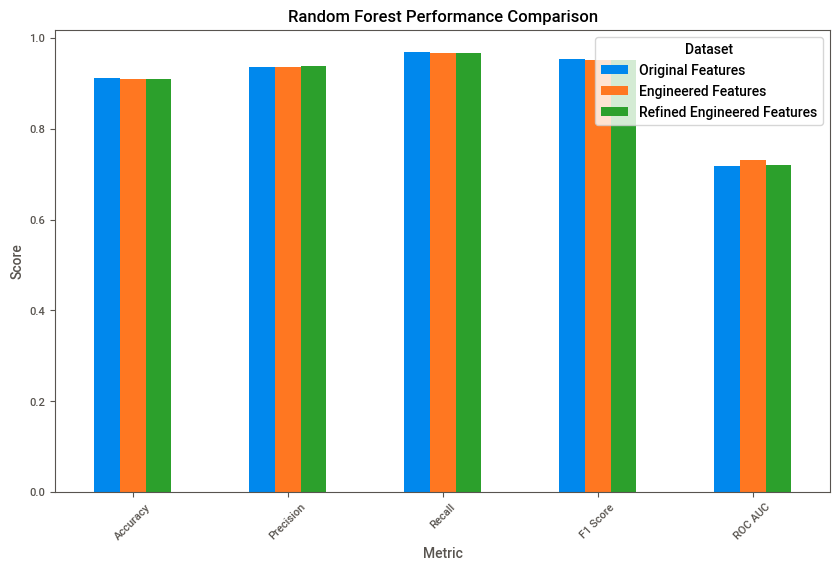

In [ ]:
# visualize comparison

comparison_plot = comparison_df.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Random Forest Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(title="Dataset")

plt.show()

Original ROC AUC: 0.7183
Engineered ROC AUC: 0.7304
Refined ROC AUC: 0.7206

Feature engineering slightly improved the model’s ability to separate successful and failed launches, as shown by the higher ROC AUC. However, the refined feature set did not improve performance compared to the full engineered set, suggesting that removing features and grouping rare categories may have reduced some useful signal.

I will use my main modeling methods on the full engineered dataset.

# **MODELING**

### LOGISTIC REGRESSION

In [ ]:
# LOGISTIC REGRESSION
# TRAIN / TEST SPLIT

from sklearn.model_selection import train_test_split

X_log = X_engineered.copy()
y_log = y_engineered.copy()

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y_log,
    test_size=0.2,
    stratify=y_log,
    random_state=42
)

print("Training shape:", X_train_log.shape)
print("Test shape:", X_test_log.shape)

Training shape: (5293, 16)
Test shape: (1324, 16)


In [ ]:
# LOGISTIC REGRESSION
# PREPROCESSING

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# create copies
X_train_log = X_train_log.copy()
X_test_log = X_test_log.copy()

# convert datetime into numeric timestamp
X_train_log["launch_timestamp"] = (
    X_train_log["dt_min"].astype("int64") // 10**9
)

X_test_log["launch_timestamp"] = (
    X_test_log["dt_min"].astype("int64") // 10**9
)

# drop original datetime column
X_train_log = X_train_log.drop(columns=["dt_min"])
X_test_log = X_test_log.drop(columns=["dt_min"])

# identify categorical and numeric columns
categorical_features_log = X_train_log.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features_log = X_train_log.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features_log)

print("\nNumeric Features:")
print(numeric_features_log)

# preprocessing pipeline
preprocessor_log = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_log
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_log
        )
    ]
)

# fit and transform training data
X_train_log_processed = preprocessor_log.fit_transform(
    X_train_log
)

# transform test data
X_test_log_processed = preprocessor_log.transform(
    X_test_log
)

print("\nProcessed training shape:")
print(X_train_log_processed.shape)

print("\nProcessed test shape:")
print(X_test_log_processed.shape)

Categorical Features:
['site_raw', 'pad_raw', 'vehicle', 'agency', 'lv_state', 'agency_grouped', 'vehicle_grouped']

Numeric Features:
['year', 'n_payload_rows', 'launch_decade', 'commercial_era', 'years_since_1957', 'agency_launch_count', 'vehicle_launch_count', 'state_launch_count', 'launch_timestamp']

Processed training shape:
(5293, 818)

Processed test shape:
(1324, 818)


In [ ]:
# BASELINE LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# initialize model
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# train model
log_model.fit(
    X_train_log_processed,
    y_train_log
)

# predictions
y_pred_log = log_model.predict(
    X_test_log_processed
)

# prediction probabilities
y_prob_log = log_model.predict_proba(
    X_test_log_processed
)[:, 1]

# evaluation metrics
accuracy_log = accuracy_score(
    y_test_log,
    y_pred_log
)

precision_log = precision_score(
    y_test_log,
    y_pred_log
)

recall_log = recall_score(
    y_test_log,
    y_pred_log
)

f1_log = f1_score(
    y_test_log,
    y_pred_log
)

roc_auc_log = roc_auc_score(
    y_test_log,
    y_prob_log
)

# print results
print("=== Logistic Regression ===")

print(f"Accuracy: {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall: {recall_log:.4f}")
print(f"F1 Score: {f1_log:.4f}")
print(f"ROC AUC: {roc_auc_log:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_log,
        y_pred_log
    )
)

=== Logistic Regression ===
Accuracy: 0.8240
Precision: 0.9551
Recall: 0.8499
F1 Score: 0.8994
ROC AUC: 0.7299

Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.50      0.30        98
           1       0.96      0.85      0.90      1226

    accuracy                           0.82      1324
   macro avg       0.58      0.67      0.60      1324
weighted avg       0.90      0.82      0.85      1324



Logistic Regression performs worse on overall accuracy,
but detects failures much better than Random Forest.

That matters because failures are rare,
failures are operationally important,
identifying failures may matter more than maximizing accuracy.

In [ ]:
# HYPERPARAMETER TUNING
# LOGISTIC REGRESSION

from sklearn.model_selection import GridSearchCV

param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    param_grid=param_grid_log,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_log.fit(X_train_log_processed, y_train_log)

print("Best parameters:", grid_log.best_params_)
print("Best CV ROC AUC:", grid_log.best_score_)

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC AUC: 0.7581112016374222


In [ ]:
# EVALUATE TUNED LOGISTIC REGRESSION

best_log_model = grid_log.best_estimator_

y_pred_log_tuned = best_log_model.predict(X_test_log_processed)
y_prob_log_tuned = best_log_model.predict_proba(X_test_log_processed)[:, 1]

accuracy_log_tuned = accuracy_score(y_test_log, y_pred_log_tuned)
precision_log_tuned = precision_score(y_test_log, y_pred_log_tuned)
recall_log_tuned = recall_score(y_test_log, y_pred_log_tuned)
f1_log_tuned = f1_score(y_test_log, y_pred_log_tuned)
roc_auc_log_tuned = roc_auc_score(y_test_log, y_prob_log_tuned)

print("=== Tuned Logistic Regression ===")
print(f"Accuracy: {accuracy_log_tuned:.4f}")
print(f"Precision: {precision_log_tuned:.4f}")
print(f"Recall: {recall_log_tuned:.4f}")
print(f"F1 Score: {f1_log_tuned:.4f}")
print(f"ROC AUC: {roc_auc_log_tuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log_tuned))

=== Tuned Logistic Regression ===
Accuracy: 0.7991
Precision: 0.9589
Recall: 0.8181
F1 Score: 0.8829
ROC AUC: 0.7560

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.56      0.29        98
           1       0.96      0.82      0.88      1226

    accuracy                           0.80      1324
   macro avg       0.58      0.69      0.59      1324
weighted avg       0.90      0.80      0.84      1324



In [ ]:
# LOGISTIC REGRESSION COMPARISON

log_comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Baseline Logistic Regression": [
        accuracy_log,
        precision_log,
        recall_log,
        f1_log,
        roc_auc_log
    ],

    "Tuned Logistic Regression": [
        accuracy_log_tuned,
        precision_log_tuned,
        recall_log_tuned,
        f1_log_tuned,
        roc_auc_log_tuned
    ]
})

log_comparison_df = log_comparison_df.round(4)

log_comparison_df

,Metric,Baseline Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.8240,0.7991
1,Precision,0.9551,0.9589
2,Recall,0.8499,0.8181
3,F1 Score,0.8994,0.8829
4,ROC AUC,0.7299,0.7560


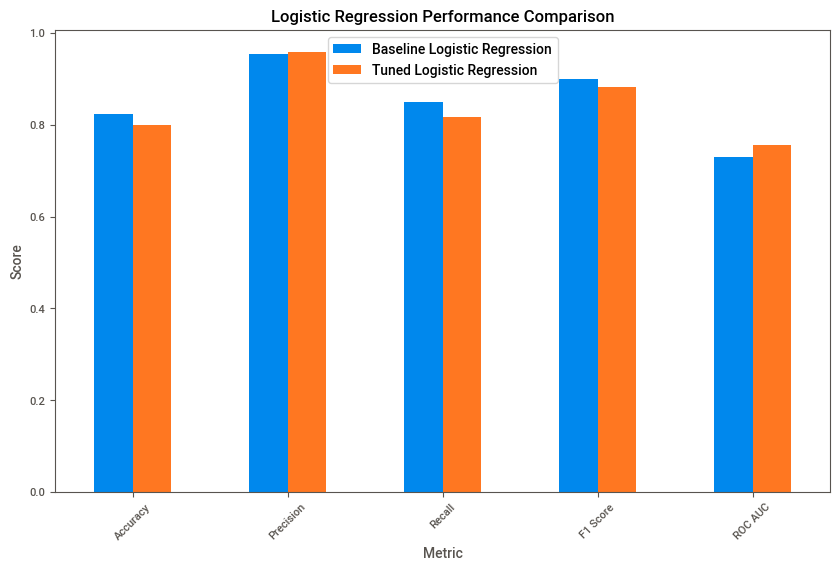

In [ ]:
# visualize logistic regression comparison

log_plot = log_comparison_df.set_index("Metric")

log_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Logistic Regression Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

The tuned model became much better at distinguishing successful vs failed launches overall.

That matters more for this problem because:

the dataset is imbalanced,
failures are rare,
and ROC AUC better captures ranking/discrimination ability.

The tuned model sacrificed some overall accuracy in exchange for:

better minority-class detection,
stronger discrimination,
and better balance across classes.

### RANDOM FOREST

In [ ]:
param_grid_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_eng_processed, y_train_eng)

print("Best parameters:", grid_rf.best_params_)
print("Best CV ROC AUC:", grid_rf.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 200}
Best CV ROC AUC: 0.767768558430713


In [ ]:
# EVALUATE TUNED RANDOM FOREST

best_rf_model = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test_eng_processed)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test_eng_processed)[:, 1]

accuracy_rf_tuned = accuracy_score(y_test_eng, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test_eng, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test_eng, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test_eng, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test_eng, y_prob_rf_tuned)

print("=== Tuned Random Forest ===")
print(f"Accuracy: {accuracy_rf_tuned:.4f}")
print(f"Precision: {precision_rf_tuned:.4f}")
print(f"Recall: {recall_rf_tuned:.4f}")
print(f"F1 Score: {f1_rf_tuned:.4f}")
print(f"ROC AUC: {roc_auc_rf_tuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_eng, y_pred_rf_tuned))

=== Tuned Random Forest ===
Accuracy: 0.8346
Precision: 0.9557
Recall: 0.8613
F1 Score: 0.9060
ROC AUC: 0.7737

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.50      0.31        98
           1       0.96      0.86      0.91      1226

    accuracy                           0.83      1324
   macro avg       0.59      0.68      0.61      1324
weighted avg       0.90      0.83      0.86      1324



ROC AUC improved.

Comparison:

Model	ROC AUC
Baseline Logistic Regression	0.7299
Tuned Logistic Regression	0.7560
Tuned Random Forest	0.7737

Random Forest is capturing:

nonlinear relationships,
interactions between agencies/vehicles/sites,
and operational patterns

better than Logistic Regression.

Failure recall remained around 0.50,
which means Random Forest improved overall discrimination without completely collapsing minority-class performance.


In [ ]:
# RANDOM FOREST COMPARISON
# BASELINE VS TUNED

rf_comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Baseline Random Forest": [
        accuracy_eng,
        precision_eng,
        recall_eng,
        f1_eng,
        roc_auc_eng
    ],

    "Tuned Random Forest": [
        accuracy_rf_tuned,
        precision_rf_tuned,
        recall_rf_tuned,
        f1_rf_tuned,
        roc_auc_rf_tuned
    ]
})

rf_comparison_df = rf_comparison_df.round(4)

rf_comparison_df

,Metric,Baseline Random Forest,Tuned Random Forest
0,Accuracy,0.9094,0.8346
1,Precision,0.9368,0.9557
2,Recall,0.9674,0.8613
3,F1 Score,0.9518,0.9060
4,ROC AUC,0.7304,0.7737


### XGBOOST

In [ ]:
!pip install xgboost

In [ ]:
# BASELINE XGBOOST MODEL

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# initialize baseline XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# train model
xgb_model.fit(
    X_train_eng_processed,
    y_train_eng
)

# predictions
y_pred_xgb = xgb_model.predict(
    X_test_eng_processed
)

# prediction probabilities
y_prob_xgb = xgb_model.predict_proba(
    X_test_eng_processed
)[:, 1]

# evaluation metrics
accuracy_xgb = accuracy_score(
    y_test_eng,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test_eng,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test_eng,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test_eng,
    y_pred_xgb
)

roc_auc_xgb = roc_auc_score(
    y_test_eng,
    y_prob_xgb
)

# print results
print("=== Baseline XGBoost ===")

print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_eng,
        y_pred_xgb
    )
)

=== Baseline XGBoost ===
Accuracy: 0.9282
Precision: 0.9394
Recall: 0.9861
F1 Score: 0.9622
ROC AUC: 0.7505

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.20      0.30        98
           1       0.94      0.99      0.96      1226

    accuracy                           0.93      1324
   macro avg       0.74      0.60      0.63      1324
weighted avg       0.91      0.93      0.91      1324



In [ ]:
# XGBOOST HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(
    X_train_eng_processed,
    y_train_eng
)

print("Best parameters:", grid_xgb.best_params_)
print("Best CV ROC AUC:", grid_xgb.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC AUC: 0.7720176116706089


In [ ]:
# EVALUATE TUNED XGBOOST

best_xgb_model = grid_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb_model.predict(
    X_test_eng_processed
)

y_prob_xgb_tuned = best_xgb_model.predict_proba(
    X_test_eng_processed
)[:, 1]

accuracy_xgb_tuned = accuracy_score(
    y_test_eng,
    y_pred_xgb_tuned
)

precision_xgb_tuned = precision_score(
    y_test_eng,
    y_pred_xgb_tuned
)

recall_xgb_tuned = recall_score(
    y_test_eng,
    y_pred_xgb_tuned
)

f1_xgb_tuned = f1_score(
    y_test_eng,
    y_pred_xgb_tuned
)

roc_auc_xgb_tuned = roc_auc_score(
    y_test_eng,
    y_prob_xgb_tuned
)

print("=== Tuned XGBoost ===")

print(f"Accuracy: {accuracy_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall: {recall_xgb_tuned:.4f}")
print(f"F1 Score: {f1_xgb_tuned:.4f}")
print(f"ROC AUC: {roc_auc_xgb_tuned:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_eng,
        y_pred_xgb_tuned
    )
)

=== Tuned XGBoost ===
Accuracy: 0.9313
Precision: 0.9362
Recall: 0.9935
F1 Score: 0.9640
ROC AUC: 0.7666

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.15      0.25        98
           1       0.94      0.99      0.96      1226

    accuracy                           0.93      1324
   macro avg       0.79      0.57      0.61      1324
weighted avg       0.92      0.93      0.91      1324



In [ ]:
# XGBOOST COMPARISON
# BASELINE VS TUNED

xgb_comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Baseline XGBoost": [
        accuracy_xgb,
        precision_xgb,
        recall_xgb,
        f1_xgb,
        roc_auc_xgb
    ],

    "Tuned XGBoost": [
        accuracy_xgb_tuned,
        precision_xgb_tuned,
        recall_xgb_tuned,
        f1_xgb_tuned,
        roc_auc_xgb_tuned
    ]
})

xgb_comparison_df = xgb_comparison_df.round(4)

xgb_comparison_df

,Metric,Baseline XGBoost,Tuned XGBoost
0,Accuracy,0.9282,0.9313
1,Precision,0.9394,0.9362
2,Recall,0.9861,0.9935
3,F1 Score,0.9622,0.9640
4,ROC AUC,0.7505,0.7666


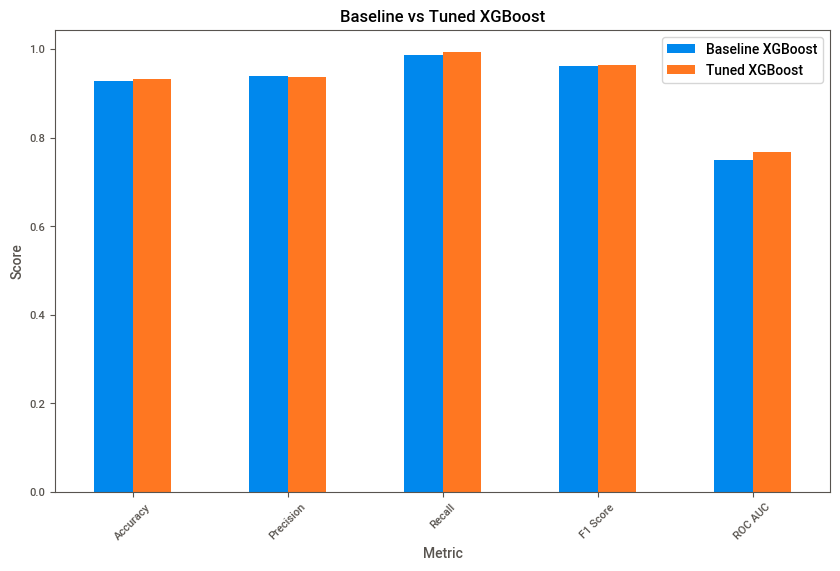

In [ ]:
# visualize XGBoost tuning impact

xgb_plot = xgb_comparison_df.set_index("Metric")

xgb_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Baseline vs Tuned XGBoost")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

### NEURAL NETWORK

In [ ]:
# BASELINE NEURAL NETWORK

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# set seed for reproducibility
tf.random.set_seed(42)

# build baseline neural network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_log_processed.shape[1],)),

    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

# compile model
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train model
history_nn = nn_model.fit(
    X_train_log_processed,
    y_train_log,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9159 - loss: 0.2971 - val_accuracy: 0.9188 - val_loss: 0.2386
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9282 - loss: 0.2168 - val_accuracy: 0.9216 - val_loss: 0.2307
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9303 - loss: 0.2006 - val_accuracy: 0.9292 - val_loss: 0.2308
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9353 - loss: 0.1895 - val_accuracy: 0.9292 - val_loss: 0.2347
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9395 - loss: 0.1816 - val_accuracy: 0.9282 - val_loss: 0.2403
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9414 - loss: 0.1757 - val_accuracy: 0.9301 - val_loss: 0.2462
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9438 - loss: 0.1713 - val_accuracy: 0.9292 - val_loss: 0.2512
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9454 - loss: 0.1680 - val_accuracy: 0.

In [ ]:
# EVALUATE BASELINE NEURAL NETWORK

y_prob_nn = nn_model.predict(X_test_log_processed).ravel()

y_pred_nn = (
    y_prob_nn >= 0.5
).astype(int)

accuracy_nn = accuracy_score(
    y_test_log,
    y_pred_nn
)

precision_nn = precision_score(
    y_test_log,
    y_pred_nn
)

recall_nn = recall_score(
    y_test_log,
    y_pred_nn
)

f1_nn = f1_score(
    y_test_log,
    y_pred_nn
)

roc_auc_nn = roc_auc_score(
    y_test_log,
    y_prob_nn
)

print("=== Baseline Neural Network ===")

print(f"Accuracy: {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall: {recall_nn:.4f}")
print(f"F1 Score: {f1_nn:.4f}")
print(f"ROC AUC: {roc_auc_nn:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_log,
        y_pred_nn
    )
)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== Baseline Neural Network ===
Accuracy: 0.9147
Precision: 0.9399
Recall: 0.9698
F1 Score: 0.9546
ROC AUC: 0.6727

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.22      0.28        98
           1       0.94      0.97      0.95      1226

    accuracy                           0.91      1324
   macro avg       0.66      0.60      0.62      1324
weighted avg       0.90      0.91      0.90      1324



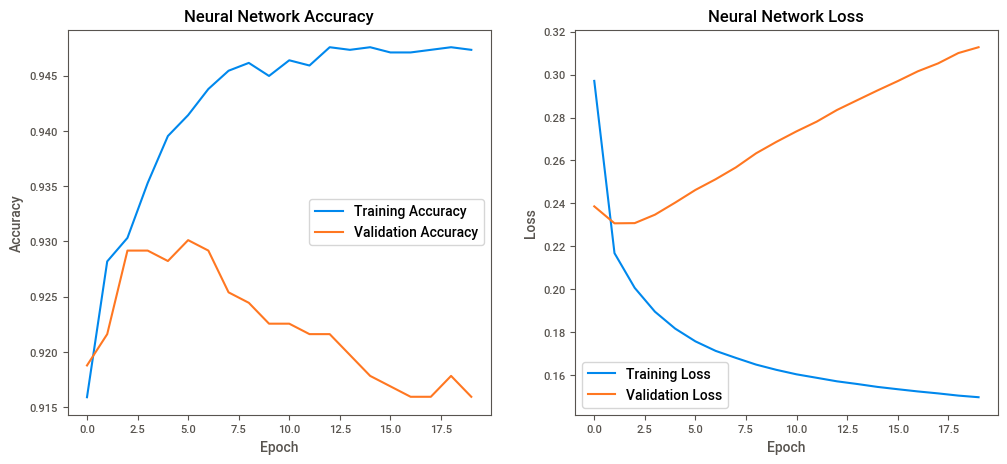

In [ ]:
# NEURAL NETWORK TRAINING HISTORY

plt.figure(figsize=(12,5))

# accuracy
plt.subplot(1,2,1)

plt.plot(
    history_nn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_nn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Accuracy")
plt.legend()

# loss
plt.subplot(1,2,2)

plt.plot(
    history_nn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_nn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Loss")
plt.legend()

plt.show()

In [ ]:
# TUNED NEURAL NETWORK

from tensorflow.keras.callbacks import EarlyStopping

# early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# build tuned neural network
nn_model_tuned = keras.Sequential([
    layers.Input(shape=(X_train_log_processed.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

# compile model
nn_model_tuned.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train model
history_nn_tuned = nn_model_tuned.fit(
    X_train_log_processed,
    y_train_log,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8812 - loss: 0.4873 - val_accuracy: 0.9188 - val_loss: 0.3208
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9270 - loss: 0.2884 - val_accuracy: 0.9188 - val_loss: 0.2521
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9275 - loss: 0.2628 - val_accuracy: 0.9188 - val_loss: 0.2385
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9275 - loss: 0.2426 - val_accuracy: 0.9188 - val_loss: 0.2349
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9277 - loss: 0.2358 - val_accuracy: 0.9188 - val_loss: 0.2317
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9282 - loss: 0.2290 - val_accuracy: 0.9197 - val_loss: 0.2297
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9294 - loss: 0.2276 - val_accuracy: 0.9216 - val_loss: 0.2293
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9306 - loss: 0.2210 - val_accuracy: 0.

In [ ]:
# EVALUATE TUNED NEURAL NETWORK

y_prob_nn_tuned = nn_model_tuned.predict(X_test_log_processed).ravel()

y_pred_nn_tuned = (y_prob_nn_tuned >= 0.5).astype(int)

accuracy_nn_tuned = accuracy_score(y_test_log, y_pred_nn_tuned)
precision_nn_tuned = precision_score(y_test_log, y_pred_nn_tuned)
recall_nn_tuned = recall_score(y_test_log, y_pred_nn_tuned)
f1_nn_tuned = f1_score(y_test_log, y_pred_nn_tuned)
roc_auc_nn_tuned = roc_auc_score(y_test_log, y_prob_nn_tuned)

print("=== Tuned Neural Network ===")
print(f"Accuracy: {accuracy_nn_tuned:.4f}")
print(f"Precision: {precision_nn_tuned:.4f}")
print(f"Recall: {recall_nn_tuned:.4f}")
print(f"F1 Score: {f1_nn_tuned:.4f}")
print(f"ROC AUC: {roc_auc_nn_tuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_nn_tuned))

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Tuned Neural Network ===
Accuracy: 0.9267
Precision: 0.9280
Recall: 0.9984
F1 Score: 0.9619
ROC AUC: 0.7469

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.03      0.06        98
           1       0.93      1.00      0.96      1226

    accuracy                           0.93      1324
   macro avg       0.76      0.51      0.51      1324
weighted avg       0.90      0.93      0.90      1324



In [ ]:
# COMPUTE CLASS WEIGHTS

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# compute balanced class weights
classes = np.unique(y_train_log)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_log
)

# convert to dictionary format
class_weights = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(6.734096692111959), 1: np.float64(0.5401020408163265)}


In [ ]:
# NEURAL NETWORK WITH CLASS WEIGHTS

tf.random.set_seed(42)

early_stopping_weighted = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

nn_model_weighted = keras.Sequential([
    layers.Input(shape=(X_train_log_processed.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

nn_model_weighted.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_nn_weighted = nn_model_weighted.fit(
    X_train_log_processed,
    y_train_log,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_weighted],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4103 - loss: 0.6697 - val_accuracy: 0.6374 - val_loss: 0.6739
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6056 - loss: 0.6331 - val_accuracy: 0.7290 - val_loss: 0.6400
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6826 - loss: 0.6023 - val_accuracy: 0.7630 - val_loss: 0.5897
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7256 - loss: 0.5850 - val_accuracy: 0.7611 - val_loss: 0.5599
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7499 - loss: 0.5501 - val_accuracy: 0.7819 - val_loss: 0.5322
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7818 - loss: 0.5306 - val_accuracy: 0.7790 - val_loss: 0.5171
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7988 - loss: 0.5152 - val_accuracy: 0.7941 - val_loss: 0.5032
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7985 - loss: 0.5014 - val_accuracy: 0.

In [ ]:
# EVALUATE WEIGHTED NEURAL NETWORK

y_prob_nn_weighted = nn_model_weighted.predict(X_test_log_processed).ravel()

y_pred_nn_weighted = (y_prob_nn_weighted >= 0.5).astype(int)

accuracy_nn_weighted = accuracy_score(y_test_log, y_pred_nn_weighted)
precision_nn_weighted = precision_score(y_test_log, y_pred_nn_weighted)
recall_nn_weighted = recall_score(y_test_log, y_pred_nn_weighted)
f1_nn_weighted = f1_score(y_test_log, y_pred_nn_weighted)
roc_auc_nn_weighted = roc_auc_score(y_test_log, y_prob_nn_weighted)

print("=== Weighted Neural Network ===")
print(f"Accuracy: {accuracy_nn_weighted:.4f}")
print(f"Precision: {precision_nn_weighted:.4f}")
print(f"Recall: {recall_nn_weighted:.4f}")
print(f"F1 Score: {f1_nn_weighted:.4f}")
print(f"ROC AUC: {roc_auc_nn_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_nn_weighted))

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Weighted Neural Network ===
Accuracy: 0.8180
Precision: 0.9506
Recall: 0.8475
F1 Score: 0.8961
ROC AUC: 0.7127

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.45      0.27        98
           1       0.95      0.85      0.90      1226

    accuracy                           0.82      1324
   macro avg       0.57      0.65      0.58      1324
weighted avg       0.89      0.82      0.85      1324



In [ ]:
# NEURAL NETWORK COMPARISON

nn_comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Baseline NN": [
        accuracy_nn,
        precision_nn,
        recall_nn,
        f1_nn,
        roc_auc_nn
    ],

    "Tuned NN": [
        accuracy_nn_tuned,
        precision_nn_tuned,
        recall_nn_tuned,
        f1_nn_tuned,
        roc_auc_nn_tuned
    ],

    "Weighted NN": [
        accuracy_nn_weighted,
        precision_nn_weighted,
        recall_nn_weighted,
        f1_nn_weighted,
        roc_auc_nn_weighted
    ]
})

nn_comparison_df = nn_comparison_df.round(4)

nn_comparison_df

,Metric,Baseline NN,Tuned NN,Weighted NN
0,Accuracy,0.9147,0.9267,0.8180
1,Precision,0.9399,0.9280,0.9506
2,Recall,0.9698,0.9984,0.8475
3,F1 Score,0.9546,0.9619,0.8961
4,ROC AUC,0.6727,0.7469,0.7127


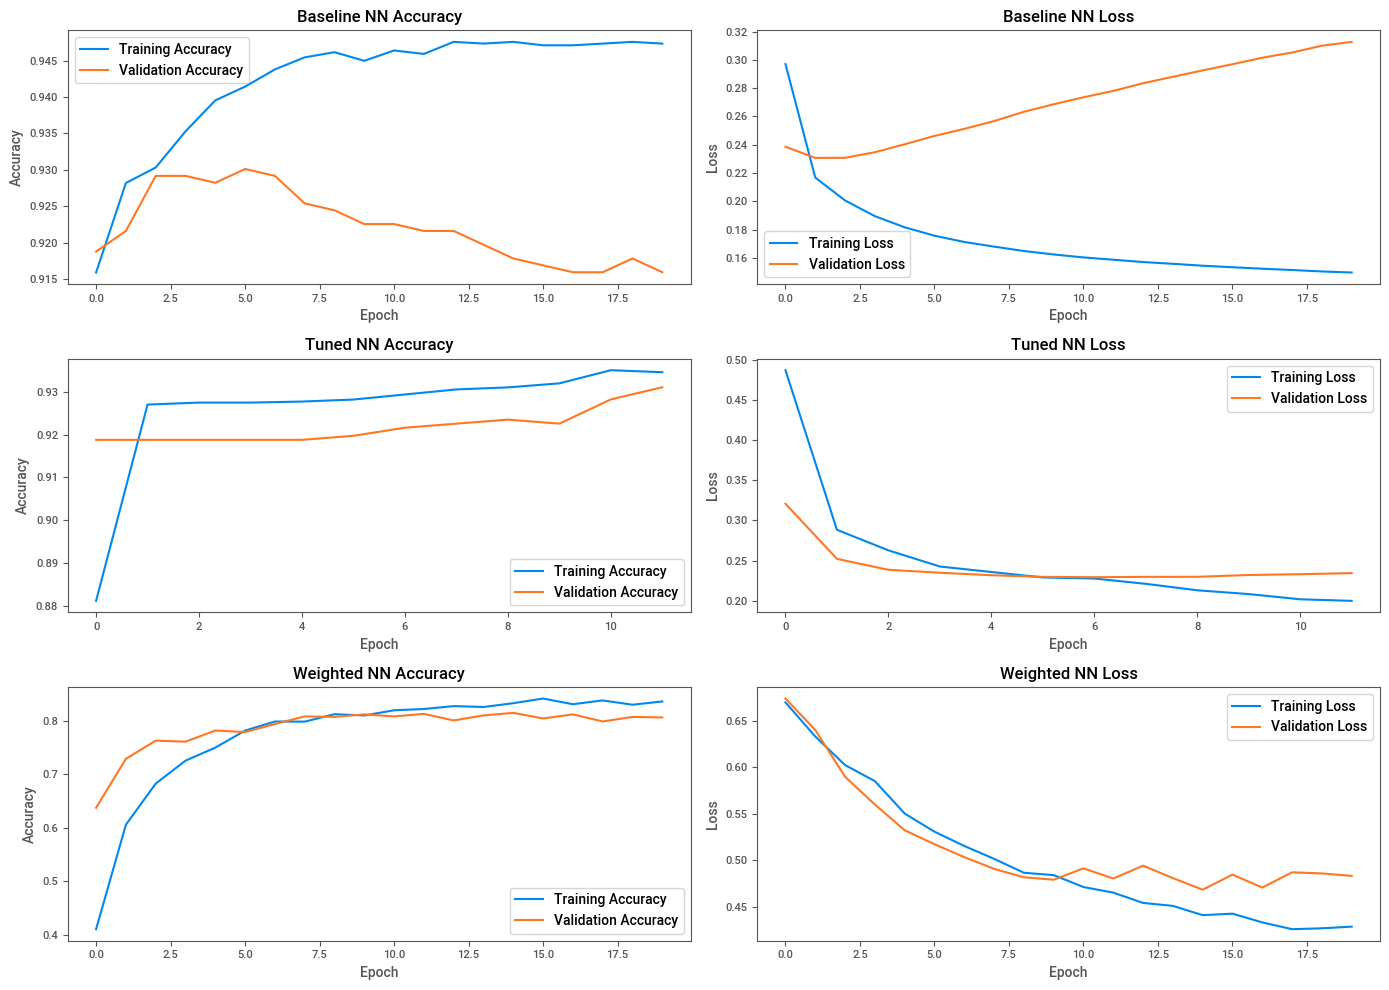

In [ ]:
# NEURAL NETWORK TRAINING COMPARISON

plt.figure(figsize=(14,10))

# BASELINE NN ACCURACY

plt.subplot(3, 2, 1)

plt.plot(
    history_nn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_nn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline NN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# BASELINE NN LOSS

plt.subplot(3, 2, 2)

plt.plot(
    history_nn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_nn.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline NN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# TUNED NN ACCURACY

plt.subplot(3, 2, 3)

plt.plot(
    history_nn_tuned.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_nn_tuned.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Tuned NN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# TUNED NN LOSS

plt.subplot(3, 2, 4)

plt.plot(
    history_nn_tuned.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_nn_tuned.history["val_loss"],
    label="Validation Loss"
)

plt.title("Tuned NN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# WEIGHTED NN ACCURACY

plt.subplot(3, 2, 5)

plt.plot(
    history_nn_weighted.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_nn_weighted.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Weighted NN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# WEIGHTED NN LOSS

plt.subplot(3, 2, 6)

plt.plot(
    history_nn_weighted.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_nn_weighted.history["val_loss"],
    label="Validation Loss"
)

plt.title("Weighted NN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### STACKING ENSEMBLE

In [ ]:
# STACKING ENSEMBLE MODEL

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# base models: best tuned versions
base_models = [
    ("logistic", best_log_model),
    ("random_forest", best_rf_model),
    ("xgboost", best_xgb_model)
]

# meta-model learns how to combine base model predictions
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

# train stacking model
stacking_model.fit(
    X_train_eng_processed,
    y_train_eng
)

# predictions
y_pred_stack = stacking_model.predict(X_test_eng_processed)

# probabilities
y_prob_stack = stacking_model.predict_proba(X_test_eng_processed)[:, 1]

# evaluation
accuracy_stack = accuracy_score(y_test_eng, y_pred_stack)
precision_stack = precision_score(y_test_eng, y_pred_stack)
recall_stack = recall_score(y_test_eng, y_pred_stack)
f1_stack = f1_score(y_test_eng, y_pred_stack)
roc_auc_stack = roc_auc_score(y_test_eng, y_prob_stack)

print("=== Stacking Ensemble ===")
print(f"Accuracy: {accuracy_stack:.4f}")
print(f"Precision: {precision_stack:.4f}")
print(f"Recall: {recall_stack:.4f}")
print(f"F1 Score: {f1_stack:.4f}")
print(f"ROC AUC: {roc_auc_stack:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_eng, y_pred_stack))

=== Stacking Ensemble ===
Accuracy: 0.8142
Precision: 0.9631
Recall: 0.8312
F1 Score: 0.8923
ROC AUC: 0.7771

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.60      0.32        98
           1       0.96      0.83      0.89      1226

    accuracy                           0.81      1324
   macro avg       0.59      0.72      0.61      1324
weighted avg       0.91      0.81      0.85      1324



The ensemble was best at distinguishing successful launches from failures overall.

failure recall improved to 0.60,
which is better than:
Logistic Regression,
Random Forest,
Neural Network,
XGBoost.



# **COMPARISON**

In [ ]:
# FINAL MODEL COMPARISON

final_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network",
        "Stacking Ensemble"
    ],

    "Accuracy": [
        accuracy_log_tuned,
        accuracy_rf_tuned,
        accuracy_xgb_tuned,
        accuracy_nn_tuned,
        accuracy_stack
    ],

    "Precision": [
        precision_log_tuned,
        precision_rf_tuned,
        precision_xgb_tuned,
        precision_nn_tuned,
        precision_stack
    ],

    "Recall": [
        recall_log_tuned,
        recall_rf_tuned,
        recall_xgb_tuned,
        recall_nn_tuned,
        recall_stack
    ],

    "F1 Score": [
        f1_log_tuned,
        f1_rf_tuned,
        f1_xgb_tuned,
        f1_nn_tuned,
        f1_stack
    ],

    "ROC AUC": [
        roc_auc_log_tuned,
        roc_auc_rf_tuned,
        roc_auc_xgb_tuned,
        roc_auc_nn_tuned,
        roc_auc_stack
    ]
})

final_comparison_df = final_comparison_df.round(4)

final_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7991,0.9589,0.8181,0.8829,0.7560
1,Random Forest,0.8346,0.9557,0.8613,0.9060,0.7737
2,XGBoost,0.9313,0.9362,0.9935,0.9640,0.7666
3,Neural Network,0.9267,0.9280,0.9984,0.9619,0.7469
4,Stacking Ensemble,0.8142,0.9631,0.8312,0.8923,0.7771


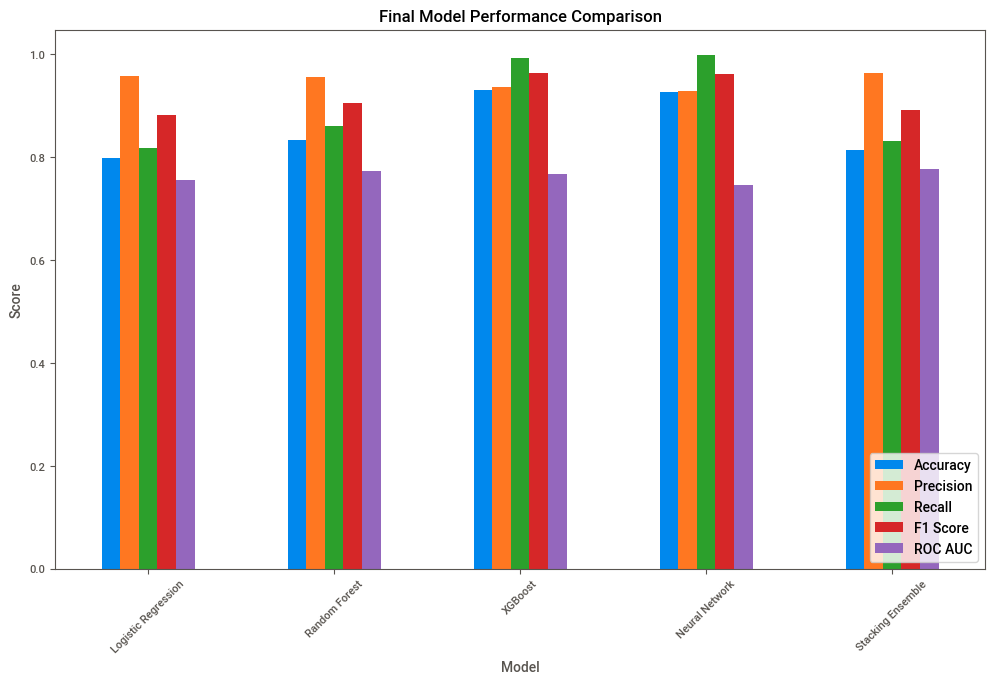

In [ ]:
# FINAL MODEL COMPARISON PLOT

comparison_plot = final_comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")

plt.show()



Main takeaways:

XGBoost achieved the strongest overall balance of accuracy, recall, F1 score, and ROC AUC among the standalone models.
Neural Network achieved very high recall and F1 score, but its ROC AUC remained lower than XGBoost, suggesting weaker overall discrimination between successful and failed launches.
Logistic Regression had the lowest overall performance but remained valuable as an interpretable baseline and demonstrated relatively balanced minority-class behavior.
Random Forest improved substantially after tuning and performed well overall, though XGBoost slightly outperformed it across most metrics.
Stacking Ensemble achieved the highest ROC AUC score overall, suggesting the best ability to distinguish between successful and failed launches across classification thresholds. However, this improvement came at the cost of increased model complexity and somewhat lower overall accuracy compared to XGBoost.

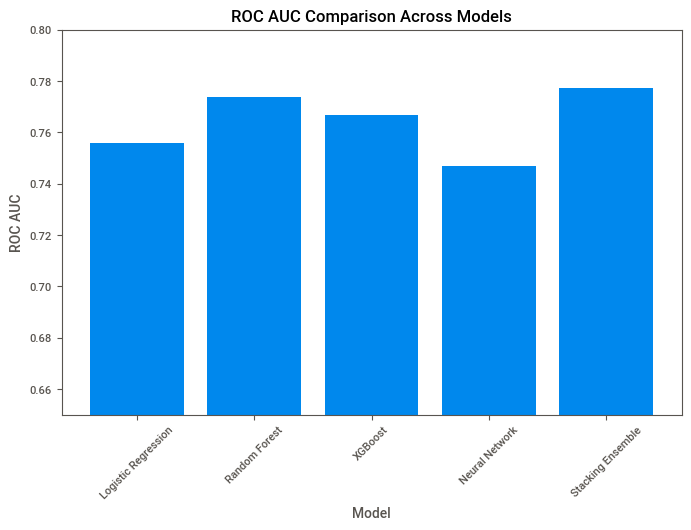

In [ ]:
# ROC AUC COMPARISON

plt.figure(figsize=(8,5))

plt.bar(
    final_comparison_df["Model"],
    final_comparison_df["ROC AUC"]
)

plt.title("ROC AUC Comparison Across Models")
plt.ylabel("ROC AUC")
plt.xlabel("Model")

plt.xticks(rotation=45)

plt.ylim(0.65, 0.80)

plt.show()

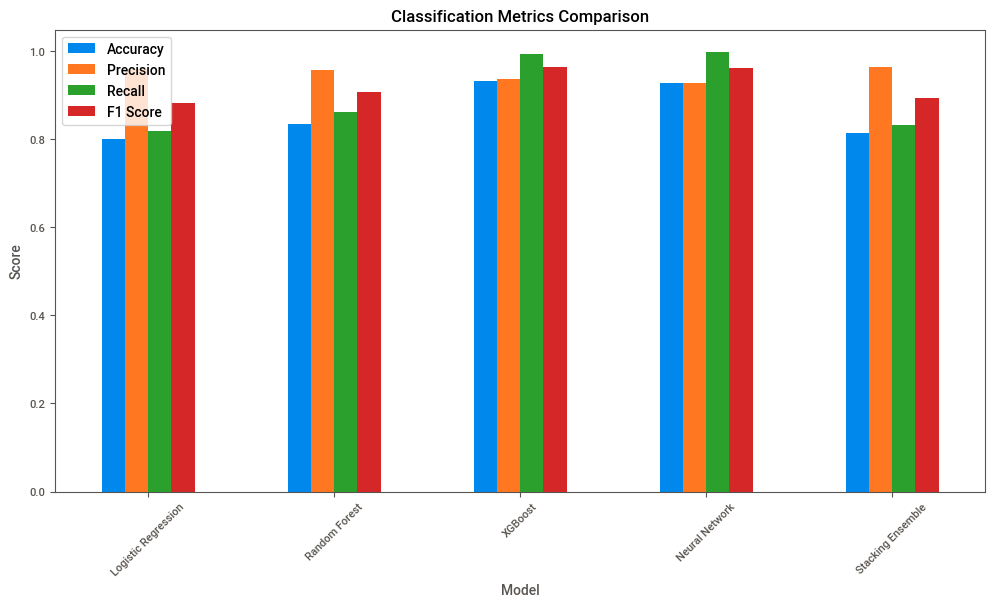

In [ ]:
# ACCURACY / PRECISION / RECALL / F1

metrics_subset = final_comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
]

metrics_plot = metrics_subset.set_index("Model")

metrics_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Classification Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

In [ ]:
feature_names = preprocessor_eng.get_feature_names_out()

In [ ]:
log_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": abs(best_log_model.coef_[0])
}).sort_values("Importance", ascending=False)

log_top5 = log_importance.head(5)
log_top5["Model"] = "Logistic Regression"

log_top5

/tmp/ipykernel_10968/1939056925.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  log_top5["Model"] = "Logistic Regression"


,Feature,Importance,Model
463,cat__vehicle_N-1 11A52,0.829247,Logistic Regression
121,cat__pad_raw_LC19,0.771674,Logistic Regression
58,cat__site_raw_YJ,0.764015,Logistic Regression
83,cat__pad_raw_L,0.755050,Logistic Regression
493,cat__vehicle_Proton-M/DM-3,0.753801,Logistic Regression


In [ ]:
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_top5 = rf_importance.head(5)
rf_top5["Model"] = "Random Forest"

rf_top5

/tmp/ipykernel_10968/947253849.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rf_top5["Model"] = "Random Forest"


,Feature,Importance,Model
815,remainder__vehicle_launch_count,0.104298,Random Forest
817,remainder__launch_timestamp,0.095882,Random Forest
809,remainder__year,0.087481,Random Forest
813,remainder__years_since_1957,0.086426,Random Forest
811,remainder__launch_decade,0.049445,Random Forest


In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_top5 = xgb_importance.head(5)
xgb_top5["Model"] = "XGBoost"

xgb_top5

/tmp/ipykernel_10968/2143411862.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgb_top5["Model"] = "XGBoost"


,Feature,Importance,Model
815,remainder__vehicle_launch_count,0.062163,XGBoost
769,cat__lv_state_SU,0.061712,XGBoost
817,remainder__launch_timestamp,0.050680,XGBoost
814,remainder__agency_launch_count,0.035774,XGBoost
813,remainder__years_since_1957,0.030579,XGBoost


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

feature_names = preprocessor_eng.get_feature_names_out()

# convert sparse matrices to dense if needed
X_test_array = X_test_eng_processed.toarray() if hasattr(X_test_eng_processed, "toarray") else X_test_eng_processed

In [ ]:
def permutation_importance_auc(model, X, y, feature_names, model_type="sklearn", top_n=5):
    baseline_probs = (
        model.predict(X).ravel()
        if model_type == "keras"
        else model.predict_proba(X)[:, 1]
    )

    baseline_auc = roc_auc_score(y, baseline_probs)

    importances = []

    for i, feature in enumerate(feature_names):
        X_permuted = X.copy()
        np.random.shuffle(X_permuted[:, i])

        permuted_probs = (
            model.predict(X_permuted, verbose=0).ravel()
            if model_type == "keras"
            else model.predict_proba(X_permuted)[:, 1]
        )

        permuted_auc = roc_auc_score(y, permuted_probs)
        importance = baseline_auc - permuted_auc

        importances.append((feature, importance))

    importance_df = pd.DataFrame(
        importances,
        columns=["Feature", "Importance"]
    ).sort_values("Importance", ascending=False)

    return importance_df.head(top_n)

In [ ]:
# Top 5 features for each model

log_top5 = permutation_importance_auc(
    best_log_model,
    X_test_array,
    y_test_eng,
    feature_names,
    model_type="sklearn"
)
log_top5["Model"] = "Logistic Regression"

rf_top5 = permutation_importance_auc(
    best_rf_model,
    X_test_array,
    y_test_eng,
    feature_names,
    model_type="sklearn"
)
rf_top5["Model"] = "Random Forest"

xgb_top5 = permutation_importance_auc(
    best_xgb_model,
    X_test_array,
    y_test_eng,
    feature_names,
    model_type="sklearn"
)
xgb_top5["Model"] = "XGBoost"

nn_top5 = permutation_importance_auc(
    nn_model_tuned,
    X_test_array,
    y_test_eng,
    feature_names,
    model_type="keras"
)
nn_top5["Model"] = "Neural Network"

stack_top5 = permutation_importance_auc(
    stacking_model,
    X_test_array,
    y_test_eng,
    feature_names,
    model_type="sklearn"
)
stack_top5["Model"] = "Stacking Ensemble"

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
top5_all_models = pd.concat(
    [log_top5, rf_top5, xgb_top5, nn_top5, stack_top5],
    ignore_index=True
)

top5_all_models

,Feature,Importance,Model
0,remainder__launch_timestamp,0.088158,Logistic Regression
1,cat__vehicle_Soyuz-U-PVB,0.000000,Logistic Regression
2,cat__vehicle_Soyuz-U2,0.000000,Logistic Regression
3,cat__vehicle_Space Shuttle,0.000000,Logistic Regression
4,cat__vehicle_Sputnik 8A91,0.000000,Logistic Regression
5,remainder__vehicle_launch_count,0.024416,Random Forest
6,remainder__agency_launch_count,0.005393,Random Forest
7,cat__site_raw_NIIP-5,0.004815,Random Forest
8,cat__agency_grouped_OTHER,0.004469,Random Forest
9,cat__vehicle_grouped_Voskhod 11A57,0.001623,Random Forest


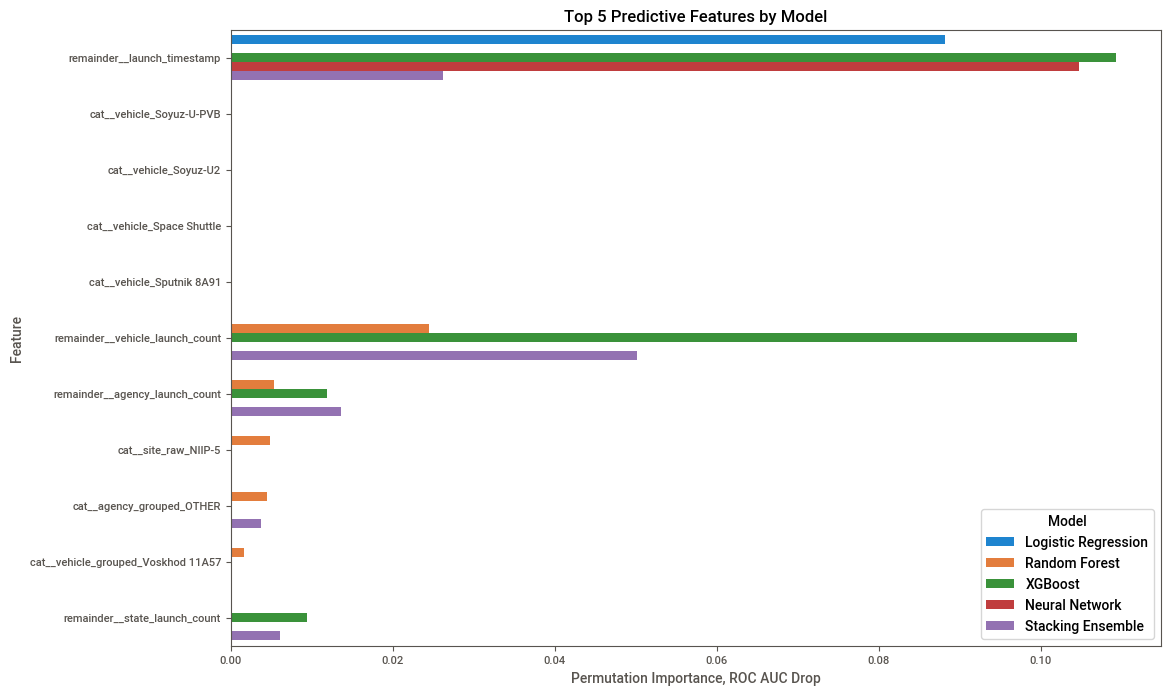

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top5_all_models,
    x="Importance",
    y="Feature",
    hue="Model"
)

plt.title("Top 5 Predictive Features by Model")
plt.xlabel("Permutation Importance, ROC AUC Drop")
plt.ylabel("Feature")
plt.show()

The best model (stacking) has vehicle_launch_count, launch_timestamp, agency_launch_count, state_launch_count, and agency_grouped_other as top features. Mature launch systems are more reliable, launch reliability improved over time, experienced organizations perfrom better, larger launch ecosystems have stronger reliability, and smaller/less established organizations behave differently.